# Visualisation Run Time

This notebook will read the txt files containing the run time of all models over the different synthetic data sets. The results will be structured and visualised to be included in the research paper. 

The results are not finalised, as some experiments are still running. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- canonical model names (added by patch_other_notebooks.py) ---
import os, sys
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _REPO_ROOT not in sys.path:
    sys.path.append(_REPO_ROOT)
from src.utils.naming import MODEL_DISPLAY_NAMES, pretty


In [2]:
# These keys are filename suffixes on disk (time_<key>.txt) and so
# must stay as-is. The mapping below routes them through the
# canonical names defined in src/utils/naming.py.
models = [
    'flowscope',
    'autoaudit', 
    'gargaml_undir', 
    'gargaml_dir'
    ]

file_to_canonical = {
    'flowscope':     'flowscope',
    'autoaudit':     'autoaudit',
    'gargaml_undir': 'gargaml_u',
    'gargaml_dir':   'gargaml_d',
}


In [3]:
model_time = {}
for model in models:
    # read file line by line, and store the time in a dictionary
    with open(f'../results/time_{model}.txt', 'r') as f:
        line = f.readline()
        time_dict = {}
        while line:
            line = line.split()
            time_dict[line[0]] = float(line[-1])
            line = f.readline()
    model_time[model] = time_dict

In [4]:
model_time

{'flowscope': {'synthetic_Barabasi-Albert_100_1_0_3': 0.2851975660014432,
  'synthetic_Barabasi-Albert_100_2_0_3': 0.07577100800699554,
  'synthetic_Barabasi-Albert_100_5_0_3': 0.09134049399290234,
  'synthetic_Erdos-Renyi_100_0_0.001_3': 0.06769746899954043,
  'synthetic_Erdos-Renyi_100_0_0.01_3': 0.06661483098287135,
  'synthetic_Watts-Strogatz_100_1_0.001_3': 0.0742830450180918,
  'synthetic_Watts-Strogatz_100_1_0.01_3': 0.0775821220013313,
  'synthetic_Watts-Strogatz_100_2_0.001_3': 0.07242353601031937,
  'synthetic_Watts-Strogatz_100_2_0.01_3': 0.07523544400464743,
  'synthetic_Watts-Strogatz_100_5_0.001_3': 0.08672217698767781,
  'synthetic_Watts-Strogatz_100_5_0.01_3': 0.09138224998605438,
  'synthetic_Barabasi-Albert_100_1_0_5': 0.07389119599247351,
  'synthetic_Barabasi-Albert_100_2_0_5': 0.08545916000730358,
  'synthetic_Barabasi-Albert_100_5_0_5': 0.08707262101233937,
  'synthetic_Erdos-Renyi_100_0_0.001_5': 0.07518670702120289,
  'synthetic_Erdos-Renyi_100_0_0.01_5': 0.0504

In [5]:
methods_list = []
length_list = []
time_list = []
for key, value in model_time.items():
    for k, v in value.items():
        methods_list.append(key)
        split_list = k.split('_')
        try:
            length_list.append(int(split_list[2]))
        except:
            length_list.append(split_list[0])
        time_list.append(v)

df = pd.DataFrame({'method': methods_list, 'length': length_list, 'time': time_list})
# Map filename keys -> canonical display names so legends pick them up.
df['method'] = df['method'].map(lambda k: pretty(file_to_canonical[k]))

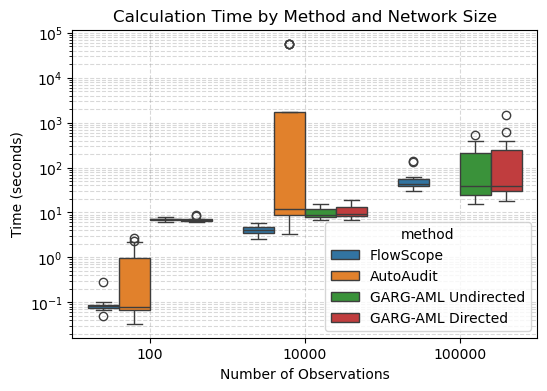

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Define the order of observation sizes
order = [100, 10000, 100000]

# Create the boxplot
plt.figure(figsize=(6, 4))
# Create the boxplot
ax = sns.boxplot(x='length', y='time', hue='method', data=df, order=order)
ax.set_yscale('log')
plt.xlabel('Number of Observations')
plt.ylabel('Time (seconds)')
plt.title('Calculation Time by Method and Network Size')
plt.grid(True,which="both",ls="--",c='gray', alpha=0.3) 
# Now get the handles and labels that Seaborn already created:
#handles, labels = ax.get_legend_handles_labels()

# re‐draw the legend at the desired location
#ax.legend(handles=handles,
#          labels=['FlowScope','AutoAudit','GARG-AML'],
#          title='Method',
#          loc='upper left')
plt.savefig('../results/time_boxplot_log.pdf')


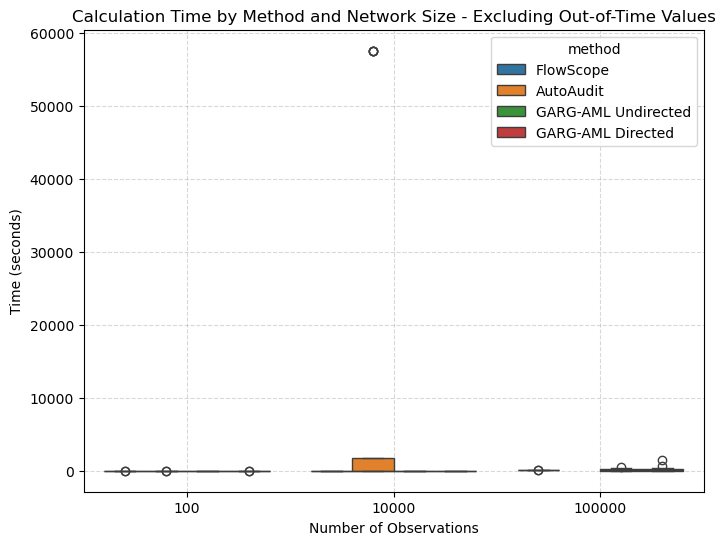

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Define the order of observation sizes
order = [100, 10000, 100000]

# Create the boxplot
plt.figure(figsize=(8, 6))
# Create the boxplot
ax = sns.boxplot(x='length', y='time', hue='method', data=df, order=order)

plt.xlabel('Number of Observations')
plt.ylabel('Time (seconds)')
plt.title('Calculation Time by Method and Network Size - Excluding Out-of-Time Values')
plt.grid(True,which="both",ls="--",c='gray', alpha=0.3)  
#handles, labels = ax.get_legend_handles_labels()

# re‐draw the legend at the desired location
#ax.legend(handles=handles,
#          labels=['FlowScope','AutoAudit','GARG-AML'],
#          title='Method',
#          loc='upper left')
plt.savefig('../results/time_boxplot_norm.pdf')

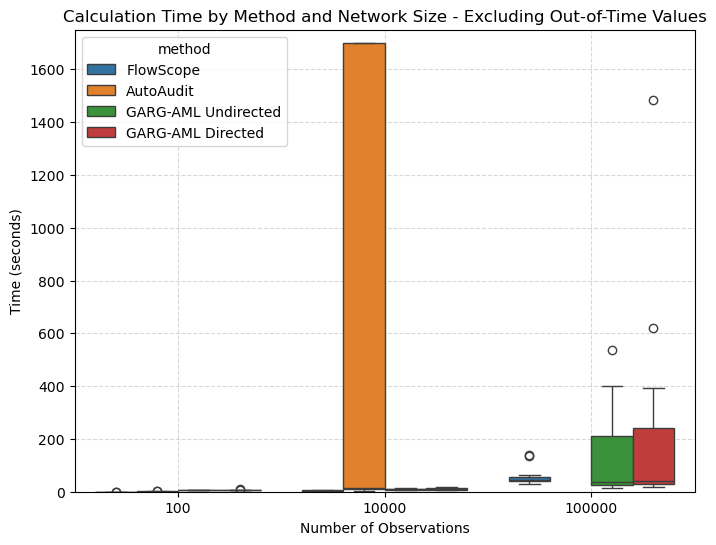

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Define the order of observation sizes
order = [100, 10000, 100000]

# Create the boxplot
plt.figure(figsize=(8, 6))
# Create the boxplot
ax = sns.boxplot(x='length', y='time', hue='method', data=df, order=order)

plt.xlabel('Number of Observations')
plt.ylim(0, 1750)
plt.ylabel('Time (seconds)')
plt.title('Calculation Time by Method and Network Size - Excluding Out-of-Time Values')
plt.grid(True,which="both",ls="--",c='gray', alpha=0.3)  
plt.savefig('../results/time_boxplot_norm_1750.pdf')


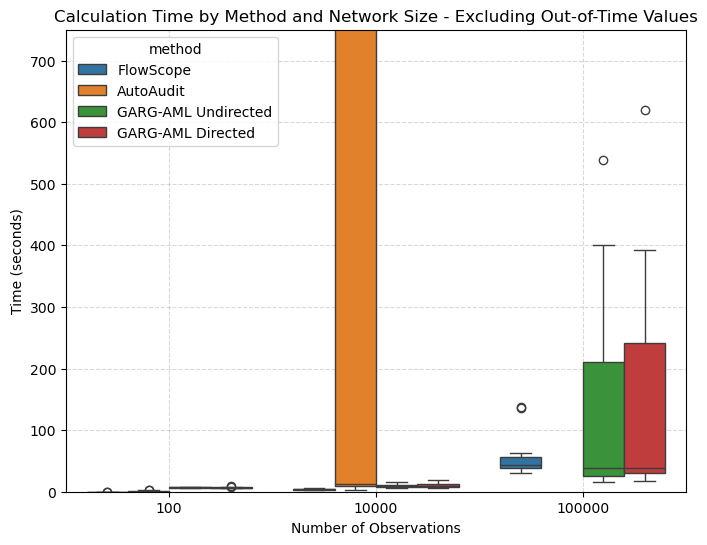

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Define the order of observation sizes
order = [100, 10000, 100000]

# Create the boxplot
plt.figure(figsize=(8, 6))
# Create the boxplot
ax = sns.boxplot(x='length', y='time', hue='method', data=df, order=order)

plt.xlabel('Number of Observations')
plt.ylim(0, 750)
plt.ylabel('Time (seconds)')
plt.title('Calculation Time by Method and Network Size - Excluding Out-of-Time Values')
plt.grid(True,which="both",ls="--",c='gray', alpha=0.3)  
plt.savefig('../results/time_boxplot_norm_750.pdf')

# IBM Data

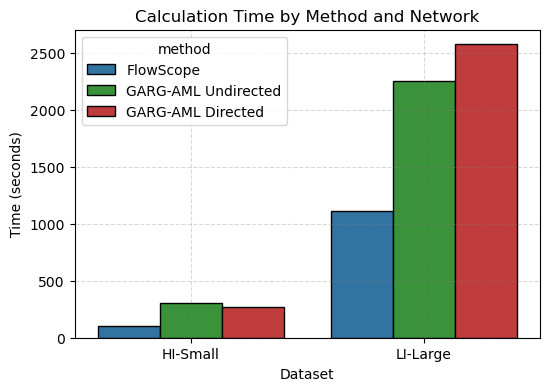

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Define the order of observation sizes
order = ['HI-Small', 'LI-Large']

custom_palette = {
    pretty('flowscope'): 'tab:blue',
    pretty('gargaml_u'): 'tab:green',
    pretty('gargaml_d'): 'tab:red',
}

# Create the boxplot
plt.figure(figsize=(6, 4))
# Create the boxplot
ax = sns.barplot(
    x='length', 
    y='time', 
    hue='method', 
    data=df[df['method'] != pretty('autoaudit')], 
    order=order,
    palette=custom_palette,
    edgecolor='black',
    )
#ax.set_yscale('log')
plt.xlabel('Dataset')
plt.ylabel('Time (seconds)')
#ax.set_ylim(bottom=1)
plt.title('Calculation Time by Method and Network')
plt.grid(True,which="both",ls="--",c='gray', alpha=0.3) 

plt.savefig('../results/time_boxplot_ibm.pdf')
